# ⚽ Premier League Match Predictor
Predicting match outcomes and simulating the 2025/26 title race using historical PL data.

**Data:** football-data.co.uk · **Seasons:** 2014/15 → 2025/26

## 1. Load & Explore Data
Load all 12 seasons, keep relevant columns, check the data looks right.

In [1]:
# 1a. Imports
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1b. Config
DATA_PATH = 'data'

SEASONS = [
    '2014-15', '2015-16', '2016-17', '2017-18', '2018-19',
    '2019-20', '2020-21', '2021-22', '2022-23', '2023-24',
    '2024-25', '2025-26'
]

COLS = [
    'season', 'Date', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'HST', 'AST',
    'HC', 'AC',
]

In [3]:
# 1c. Load Data
dfs = []
for season in SEASONS:
    temp = pd.read_csv(f'{DATA_PATH}/{season}.csv', encoding='latin1')
    temp['season'] = season
    dfs.append(temp)

raw = pd.concat(dfs, ignore_index=True)

In [4]:
# 1d. Clean & Explore
df = raw[[c for c in COLS if c in raw.columns]].copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.dropna(subset=['FTR', 'FTHG', 'FTAG'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Total matches : {len(df):,}")
print(f"Seasons       : {df['season'].nunique()}")
print(f"Date range    : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nResult distribution:")
print(df['FTR'].value_counts().to_string())
print(f"\nOver 2.5 goals: {(df['FTHG'] + df['FTAG'] > 2.5).mean():.1%} of matches")

df.head()

Total matches : 4,471
Seasons       : 12
Date range    : 2014-08-16 → 2026-03-05

Result distribution:
FTR
H    1986
A    1430
D    1055

Over 2.5 goals: 53.7% of matches


,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HST,AST,HC,AC
0,2014-15,2014-08-16,Arsenal,Crystal Palace,2.0,1.0,H,6.0,2.0,9.0,3.0
1,2014-15,2014-08-16,Leicester,Everton,2.0,2.0,D,3.0,3.0,3.0,6.0
2,2014-15,2014-08-16,Man United,Swansea,1.0,2.0,A,5.0,4.0,4.0,0.0
3,2014-15,2014-08-16,QPR,Hull,0.0,1.0,A,6.0,4.0,8.0,9.0
4,2014-15,2014-08-16,Stoke,Aston Villa,0.0,1.0,A,2.0,2.0,2.0,8.0


## 2. Feature Engineering
Build rolling form features for each team going into every match.

In [5]:
# 2a. Config
N = 5  # rolling window

In [6]:
# 2b. Helper Functions
def get_team_form(df, team, date):
    mask = (
        ((df['HomeTeam'] == team) | (df['AwayTeam'] == team)) &
        (df['Date'] < date)
    )
    return df[mask].tail(N)

def compute_form(matches, team):
    if len(matches) == 0:
        return {
            'form_pts': np.nan, 'form_gf': np.nan, 'form_ga': np.nan,
            'form_sot_f': np.nan, 'form_sot_a': np.nan
        }

    pts, gf, ga, sot_f, sot_a = [], [], [], [], []

    for _, m in matches.iterrows():
        home = m['HomeTeam'] == team
        gf.append(m['FTHG'] if home else m['FTAG'])
        ga.append(m['FTAG'] if home else m['FTHG'])

        if 'HST' in m and pd.notna(m['HST']):
            sot_f.append(m['HST'] if home else m['AST'])
            sot_a.append(m['AST'] if home else m['HST'])

        result = m['FTR']
        if (home and result == 'H') or (not home and result == 'A'):
            pts.append(3)
        elif result == 'D':
            pts.append(1)
        else:
            pts.append(0)

    return {
        'form_pts':   np.mean(pts),
        'form_gf':    np.mean(gf),
        'form_ga':    np.mean(ga),
        'form_sot_f': np.mean(sot_f) if sot_f else np.nan,
        'form_sot_a': np.mean(sot_a) if sot_a else np.nan,
    }

In [7]:
# 2c. Build Features
print("Building features")

rows = []
for _, match in df.iterrows():
    home, away, date = match['HomeTeam'], match['AwayTeam'], match['Date']

    home_form = compute_form(get_team_form(df, home, date), home)
    away_form = compute_form(get_team_form(df, away, date), away)

    rows.append({
        'season':       match['season'],
        'Date':         date,
        'HomeTeam':     home,
        'AwayTeam':     away,
        'FTHG':         match['FTHG'],
        'FTAG':         match['FTAG'],
        'FTR':          match['FTR'],
        'h_form_pts':   home_form['form_pts'],
        'h_form_gf':    home_form['form_gf'],
        'h_form_ga':    home_form['form_ga'],
        'h_form_sot_f': home_form['form_sot_f'],
        'h_form_sot_a': home_form['form_sot_a'],
        'a_form_pts':   away_form['form_pts'],
        'a_form_gf':    away_form['form_gf'],
        'a_form_ga':    away_form['form_ga'],
        'a_form_sot_f': away_form['form_sot_f'],
        'a_form_sot_a': away_form['form_sot_a'],
        'pts_diff':     home_form['form_pts']   - away_form['form_pts'],
        'gf_diff':      home_form['form_gf']    - away_form['form_gf'],
        'ga_diff':      home_form['form_ga']    - away_form['form_ga'],
        'sot_diff':     (home_form['form_sot_f'] or 0) - (away_form['form_sot_f'] or 0),
        'result':       match['FTR'],
        'over_2_5':     int((match['FTHG'] + match['FTAG']) > 2.5),
    })

features = pd.DataFrame(rows)
print("Building features Done")

Building features
Building features Done


In [8]:
# 2d. Clean & Verify
features = features.dropna(subset=['h_form_pts', 'a_form_pts'])
features = features.reset_index(drop=True)

print(f"Total matches with features : {len(features):,}")
print(f"Dropped (not enough history): {len(df) - len(features):,}")
features.head(3)

Total matches with features : 4,446
Dropped (not enough history): 25


,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,h_form_pts,h_form_gf,h_form_ga,...,a_form_gf,a_form_ga,a_form_sot_f,a_form_sot_a,pts_diff,gf_diff,ga_diff,sot_diff,result,over_2_5
0,2014-15,2014-08-23,Swansea,Burnley,1.0,0.0,H,3.0,2.0,1.0,...,1.0,3.0,2.0,3.0,3.0,1.0,-2.0,2.0,H,0
1,2014-15,2014-08-23,Aston Villa,Newcastle,0.0,0.0,D,3.0,1.0,0.0,...,0.0,2.0,0.0,5.0,3.0,1.0,-2.0,2.0,D,0
2,2014-15,2014-08-23,Chelsea,Leicester,2.0,0.0,H,3.0,3.0,1.0,...,2.0,2.0,3.0,3.0,2.0,1.0,-1.0,0.0,H,0


## 3. Train Models
Train Win/Draw/Loss and Over/Under 2.5 models on seasons 2014/15 → 2024/25. Using Logistic Regression and Gradient Boosting.

In [9]:
# 3a. Imports
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from xgboost import XGBClassifier


In [10]:
# 3b. Split — train on 2014/15 → 2024/25, test on 2025/26
FEATURE_COLS = [
    'h_form_pts', 'h_form_gf', 'h_form_ga', 'h_form_sot_f', 'h_form_sot_a',
    'a_form_pts', 'a_form_gf', 'a_form_ga', 'a_form_sot_f', 'a_form_sot_a',
    'pts_diff', 'gf_diff', 'ga_diff', 'sot_diff'
]

train = features[features['season'] != '2025-26'].dropna(subset=FEATURE_COLS)
test  = features[features['season'] == '2025-26'].dropna(subset=FEATURE_COLS)

X_train = train[FEATURE_COLS]
X_test  = test[FEATURE_COLS]

print(f"Train : {len(train):,} matches")
print(f"Test  : {len(test):,} matches")

Train : 4,155 matches
Test  : 291 matches


In [11]:
# 3c. Train Win/Draw/Loss Model
result_map = {'H': 0, 'D': 1, 'A': 2}

y_train_result = train['result'].map(result_map)
y_test_result  = test['result'].map(result_map)

outcome_model = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 4,
    learning_rate    = 0.04,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    min_child_weight = 5,
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    random_state     = 42,
)
outcome_model.fit(X_train, y_train_result)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [12]:
# 3d. Train Logistic Regression — Win/Draw/Loss
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_outcome = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_outcome.fit(X_train, y_train_result)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [13]:
# 3e. Train Over/Under 2.5 Model
y_train_ou = train['over_2_5']
y_test_ou  = test['over_2_5']

ou_model = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 4,
    learning_rate    = 0.04,
    subsample        = 0.8,
    colsample_bytree = 0.7,
    eval_metric      = 'logloss',
    random_state     = 42,
)
ou_model.fit(X_train, y_train_ou)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
# 3f. Train Logistic Regression — Over/Under
lr_ou = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_ou.fit(X_train, y_train_ou)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## 4. Evaluate Models
Confusion matrix, accuracy, log loss — how well does the model predict?

In [15]:
# 4a. Imports
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

── XGBoost Holdout (2025/26) — Win/Draw/Loss ──
Accuracy : 43.3%
Log Loss : 1.0743  (naive baseline ~1.10)

              precision    recall  f1-score   support

    Home Win       0.45      0.75      0.56       123
        Draw       0.25      0.03      0.05        76
    Away Win       0.40      0.35      0.37        92

    accuracy                           0.43       291
   macro avg       0.37      0.37      0.33       291
weighted avg       0.38      0.43      0.37       291



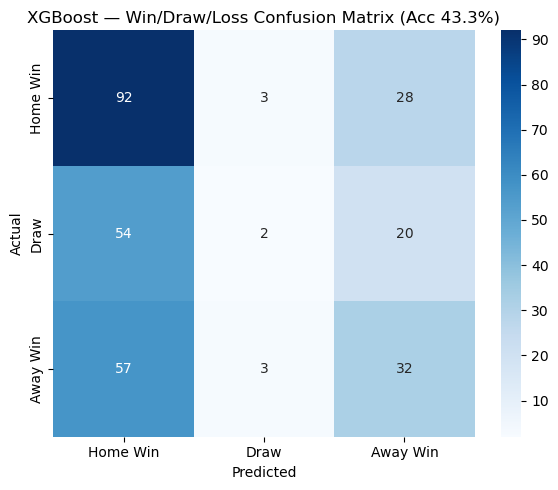

In [16]:
# 4b. Holdout — XGBoost Win/Draw/Loss + Confusion Matrix
result_labels = ['Home Win', 'Draw', 'Away Win']

y_pred_result = outcome_model.predict(X_test)
y_prob_result = outcome_model.predict_proba(X_test)

acc = accuracy_score(y_test_result, y_pred_result)
ll  = log_loss(y_test_result, y_prob_result)

print(f"── XGBoost Holdout (2025/26) — Win/Draw/Loss ──")
print(f"Accuracy : {acc:.1%}")
print(f"Log Loss : {ll:.4f}  (naive baseline ~1.10)")
print(f"\n{classification_report(y_test_result, y_pred_result, target_names=result_labels)}")

cm = confusion_matrix(y_test_result, y_pred_result)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=result_labels,
            yticklabels=result_labels, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost — Win/Draw/Loss Confusion Matrix (Acc {acc:.1%})')
plt.tight_layout()
plt.show()

── XGBoost Holdout (2025/26) — Over/Under ──
Accuracy : 58.1%
Log Loss : 0.6834

              precision    recall  f1-score   support

   Under 2.5       0.55      0.46      0.50       134
    Over 2.5       0.60      0.68      0.64       157

    accuracy                           0.58       291
   macro avg       0.58      0.57      0.57       291
weighted avg       0.58      0.58      0.58       291



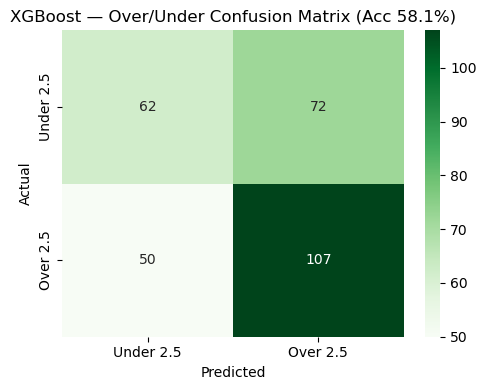

In [17]:
# 4c. Holdout — XGBoost Over/Under + Confusion Matrix
y_pred_ou = ou_model.predict(X_test)
y_prob_ou = ou_model.predict_proba(X_test)

acc_ou = accuracy_score(y_test_ou, y_pred_ou)
ll_ou  = log_loss(y_test_ou, y_prob_ou)

print(f"── XGBoost Holdout (2025/26) — Over/Under ──")
print(f"Accuracy : {acc_ou:.1%}")
print(f"Log Loss : {ll_ou:.4f}")
print(f"\n{classification_report(y_test_ou, y_pred_ou, target_names=['Under 2.5', 'Over 2.5'])}")

cm_ou = confusion_matrix(y_test_ou, y_pred_ou)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_ou, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Under 2.5', 'Over 2.5'],
            yticklabels=['Under 2.5', 'Over 2.5'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'XGBoost — Over/Under Confusion Matrix (Acc {acc_ou:.1%})')
plt.tight_layout()
plt.show()

In [18]:
# 4d. Holdout — Logistic Regression Win/Draw/Loss
lr_outcome = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_outcome.fit(X_train, y_train_result)

lr_pred_result = lr_outcome.predict(X_test)
lr_prob_result = lr_outcome.predict_proba(X_test)

lr_acc = accuracy_score(y_test_result, lr_pred_result)
lr_ll  = log_loss(y_test_result, lr_prob_result)

print(f"── Logistic Regression Holdout — Win/Draw/Loss ──")
print(f"Accuracy : {lr_acc:.1%}")
print(f"Log Loss : {lr_ll:.4f}")
print(f"\n{classification_report(y_test_result, lr_pred_result, target_names=result_labels)}")

── Logistic Regression Holdout — Win/Draw/Loss ──
Accuracy : 46.7%
Log Loss : 1.0576

              precision    recall  f1-score   support

    Home Win       0.48      0.78      0.59       123
        Draw       0.00      0.00      0.00        76
    Away Win       0.44      0.43      0.44        92

    accuracy                           0.47       291
   macro avg       0.31      0.41      0.34       291
weighted avg       0.34      0.47      0.39       291



In [19]:
# 4e. Holdout — Logistic Regression Over/Under
lr_ou = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
lr_ou.fit(X_train, y_train_ou)

lr_pred_ou = lr_ou.predict(X_test)
lr_prob_ou = lr_ou.predict_proba(X_test)

lr_acc_ou = accuracy_score(y_test_ou, lr_pred_ou)
lr_ll_ou  = log_loss(y_test_ou, lr_prob_ou)

print(f"── Logistic Regression Holdout — Over/Under ──")
print(f"Accuracy : {lr_acc_ou:.1%}")
print(f"Log Loss : {lr_ll_ou:.4f}")
print(f"\n{classification_report(y_test_ou, lr_pred_ou, target_names=['Under 2.5', 'Over 2.5'])}")

── Logistic Regression Holdout — Over/Under ──
Accuracy : 56.4%
Log Loss : 0.6896

              precision    recall  f1-score   support

   Under 2.5       0.54      0.36      0.43       134
    Over 2.5       0.57      0.74      0.65       157

    accuracy                           0.56       291
   macro avg       0.56      0.55      0.54       291
weighted avg       0.56      0.56      0.55       291



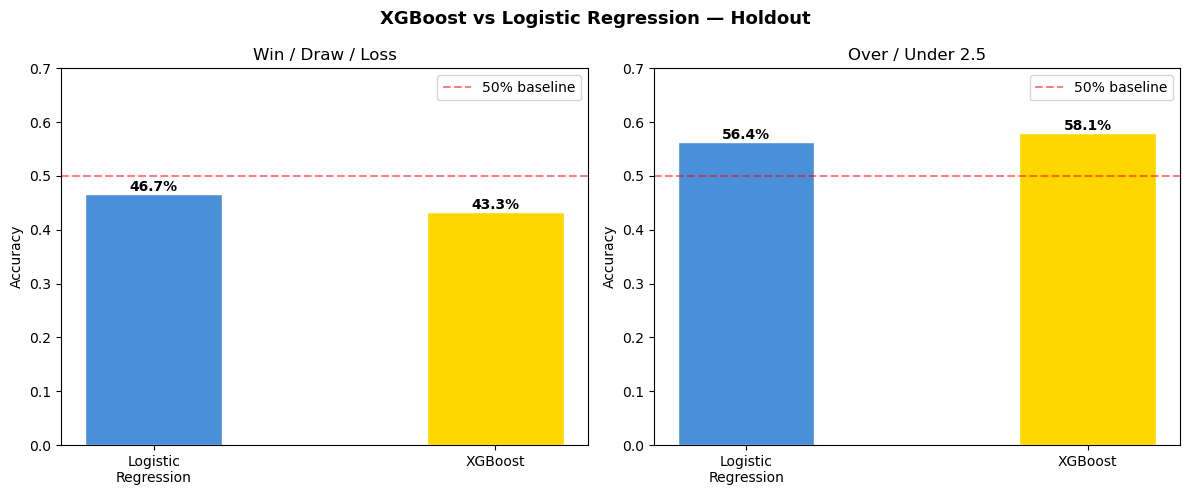

In [20]:
# 4f. XGBoost vs Logistic Regression — Holdout Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('XGBoost vs Logistic Regression — Holdout', fontsize=13, fontweight='bold')

models = ['Logistic\nRegression', 'XGBoost']
colors = ['#4a90d9', 'gold']

axes[0].bar(models, [lr_acc, acc], color=colors, edgecolor='white', width=0.4)
axes[0].set_ylim(0, 0.7)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Win / Draw / Loss')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, v in enumerate([lr_acc, acc]):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
axes[0].legend()

axes[1].bar(models, [lr_acc_ou, acc_ou], color=colors, edgecolor='white', width=0.4)
axes[1].set_ylim(0, 0.7)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Over / Under 2.5')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, v in enumerate([lr_acc_ou, acc_ou]):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# 4g. CV (TimeSeriesSplit) — XGBoost Win/Draw/Loss
train_all    = features[features['season'] != '2025-26'].dropna(subset=FEATURE_COLS)
X_all        = train_all[FEATURE_COLS]
y_all_result = train_all['result'].map(result_map)
y_all_ou     = train_all['over_2_5']

tscv = TimeSeriesSplit(n_splits=5)

cv_scores_result = cross_val_score(
    outcome_model, X_all, y_all_result,
    cv=tscv, scoring='accuracy'
)

print(f"── TimeSeriesSplit CV (5 folds) — XGBoost Win/Draw/Loss ──")
for i, score in enumerate(cv_scores_result):
    print(f"  Fold {i+1} : {score:.1%}")
print(f"  Mean    : {cv_scores_result.mean():.1%}")
print(f"  Std     : {cv_scores_result.std():.1%}")

── TimeSeriesSplit CV (5 folds) — XGBoost Win/Draw/Loss ──
  Fold 1 : 47.7%
  Fold 2 : 49.3%
  Fold 3 : 43.8%
  Fold 4 : 50.0%
  Fold 5 : 48.4%
  Mean    : 47.8%
  Std     : 2.2%


In [22]:
# 4h. CV (TimeSeriesSplit) — XGBoost Over/Under
cv_scores_ou = cross_val_score(
    ou_model, X_all, y_all_ou,
    cv=tscv, scoring='accuracy'
)

print(f"── TimeSeriesSplit CV (5 folds) — XGBoost Over/Under ──")
for i, score in enumerate(cv_scores_ou):
    print(f"  Fold {i+1} : {score:.1%}")
print(f"  Mean    : {cv_scores_ou.mean():.1%}")
print(f"  Std     : {cv_scores_ou.std():.1%}")

── TimeSeriesSplit CV (5 folds) — XGBoost Over/Under ──
  Fold 1 : 52.3%
  Fold 2 : 53.6%
  Fold 3 : 52.9%
  Fold 4 : 54.2%
  Fold 5 : 53.8%
  Mean    : 53.4%
  Std     : 0.7%


In [23]:
# 4i. CV (TimeSeriesSplit) — Logistic Regression Win/Draw/Loss
cv_scores_lr_result = cross_val_score(
    lr_outcome, X_all, y_all_result,
    cv=tscv, scoring='accuracy'
)

print(f"── TimeSeriesSplit CV (5 folds) — Logistic Win/Draw/Loss ──")
for i, score in enumerate(cv_scores_lr_result):
    print(f"  Fold {i+1} : {score:.1%}")
print(f"  Mean    : {cv_scores_lr_result.mean():.1%}")
print(f"  Std     : {cv_scores_lr_result.std():.1%}")

── TimeSeriesSplit CV (5 folds) — Logistic Win/Draw/Loss ──
  Fold 1 : 51.2%
  Fold 2 : 54.5%
  Fold 3 : 46.8%
  Fold 4 : 52.7%
  Fold 5 : 53.2%
  Mean    : 51.7%
  Std     : 2.6%


In [24]:
# 4j. CV (TimeSeriesSplit) — Logistic Regression Over/Under
cv_scores_lr_ou = cross_val_score(
    lr_ou, X_all, y_all_ou,
    cv=tscv, scoring='accuracy'
)

print(f"── TimeSeriesSplit CV (5 folds) — Logistic Over/Under ──")
for i, score in enumerate(cv_scores_lr_ou):
    print(f"  Fold {i+1} : {score:.1%}")
print(f"  Mean    : {cv_scores_lr_ou.mean():.1%}")
print(f"  Std     : {cv_scores_lr_ou.std():.1%}")

── TimeSeriesSplit CV (5 folds) — Logistic Over/Under ──
  Fold 1 : 49.6%
  Fold 2 : 54.5%
  Fold 3 : 55.6%
  Fold 4 : 53.9%
  Fold 5 : 57.1%
  Mean    : 54.1%
  Std     : 2.5%


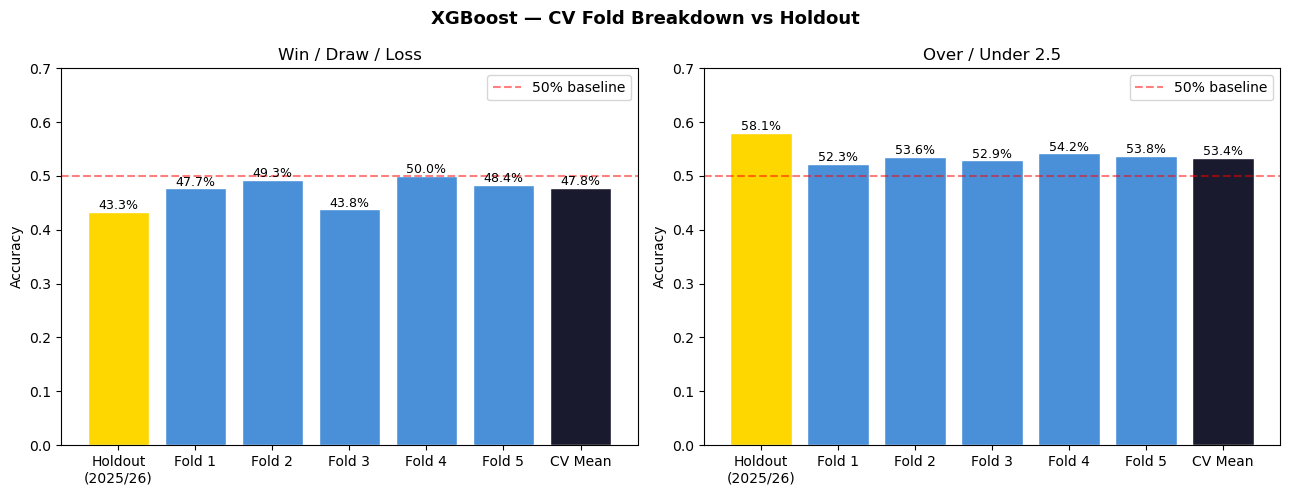

In [25]:
# 4k. CV Folds Detail Chart — XGBoost
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost — CV Fold Breakdown vs Holdout',
             fontsize=13, fontweight='bold')

methods = ['Holdout\n(2025/26)', 'Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'CV Mean']
colors  = ['gold'] + ['#4a90d9'] * 5 + ['#1a1a2e']

scores_result = [acc] + list(cv_scores_result) + [cv_scores_result.mean()]
axes[0].bar(methods, scores_result, color=colors, edgecolor='white')
axes[0].set_ylim(0, 0.7)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Win / Draw / Loss')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, v in enumerate(scores_result):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
axes[0].legend()

scores_ou_all = [acc_ou] + list(cv_scores_ou) + [cv_scores_ou.mean()]
axes[1].bar(methods, scores_ou_all, color=colors, edgecolor='white')
axes[1].set_ylim(0, 0.7)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Over / Under 2.5')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, v in enumerate(scores_ou_all):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()

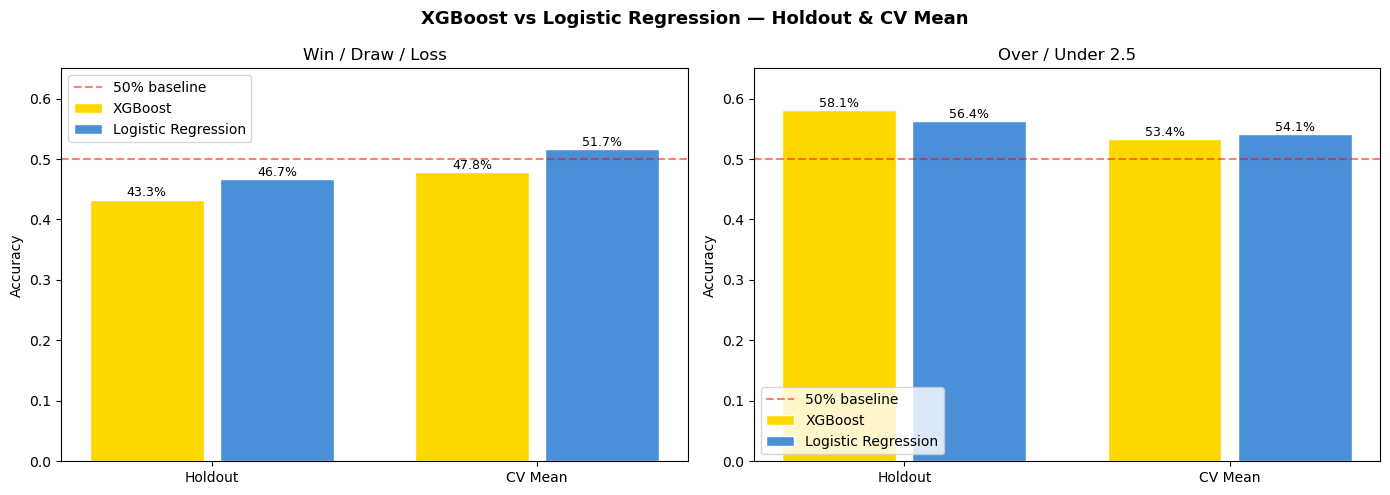

In [26]:
# 4l. Full Model Comparison — Holdout + CV Mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost vs Logistic Regression — Holdout & CV Mean',
             fontsize=13, fontweight='bold')

methods = ['Holdout', 'CV Mean']
x = range(len(methods))

xgb_result = [acc,    cv_scores_result.mean()]
lr_result  = [lr_acc, cv_scores_lr_result.mean()]

axes[0].bar([i - 0.2 for i in x], xgb_result, width=0.35,
            label='XGBoost', color='gold', edgecolor='white')
axes[0].bar([i + 0.2 for i in x], lr_result, width=0.35,
            label='Logistic Regression', color='#4a90d9', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0, 0.65)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Win / Draw / Loss')
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, (a, b) in enumerate(zip(xgb_result, lr_result)):
    axes[0].text(i - 0.2, a + 0.005, f'{a:.1%}', ha='center', fontsize=9)
    axes[0].text(i + 0.2, b + 0.005, f'{b:.1%}', ha='center', fontsize=9)
axes[0].legend()

xgb_ou = [acc_ou,    cv_scores_ou.mean()]
lr_ou_scores = [lr_acc_ou, cv_scores_lr_ou.mean()]

axes[1].bar([i - 0.2 for i in x], xgb_ou, width=0.35,
            label='XGBoost', color='gold', edgecolor='white')
axes[1].bar([i + 0.2 for i in x], lr_ou_scores, width=0.35,
            label='Logistic Regression', color='#4a90d9', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].set_ylim(0, 0.65)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Over / Under 2.5')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
for i, (a, b) in enumerate(zip(xgb_ou, lr_ou_scores)):
    axes[1].text(i - 0.2, a + 0.005, f'{a:.1%}', ha='center', fontsize=9)
    axes[1].text(i + 0.2, b + 0.005, f'{b:.1%}', ha='center', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.show()

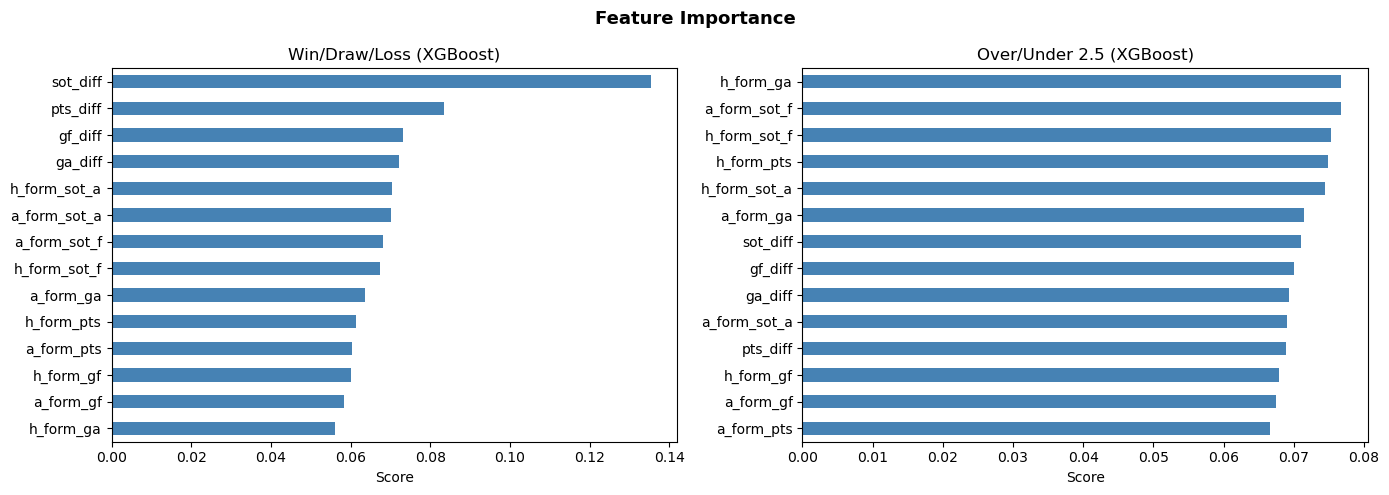

In [27]:
# 4m. Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance', fontsize=13, fontweight='bold')

for ax, model, title in zip(axes,
    [outcome_model, ou_model],
    ['Win/Draw/Loss (XGBoost)', 'Over/Under 2.5 (XGBoost)']):
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('Score')

plt.tight_layout()
plt.show()

## 5. 2025/26 Predictions vs Reality
Compare model predictions against real results from this season so far.

In [28]:
# 5a. Get 2025/26 Played Matches
played = test.copy()
played['pred_result_code'] = outcome_model.predict(X_test)
played['pred_ou']          = ou_model.predict(X_test)

result_map_inv = {0: 'H', 1: 'D', 2: 'A'}
played['pred_result'] = played['pred_result_code'].map(result_map_inv)

probs = outcome_model.predict_proba(X_test)
played['p_home_win'] = probs[:, 0]
played['p_draw']     = probs[:, 1]
played['p_away_win'] = probs[:, 2]
played['p_over_2_5'] = ou_model.predict_proba(X_test)[:, 1]

played['result_correct'] = (played['pred_result'] == played['FTR']).astype(int)
played['ou_correct']     = (played['pred_ou']     == played['over_2_5']).astype(int)

print(f"Matches predicted : {len(played)}")
print(f"Result accuracy   : {played['result_correct'].mean():.1%}")
print(f"O/U accuracy      : {played['ou_correct'].mean():.1%}")

Matches predicted : 291
Result accuracy   : 43.3%
O/U accuracy      : 58.1%


In [29]:
# 5b. Predictions Table
display_cols = [
    'Date', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'pred_result', 'result_correct',
    'p_home_win', 'p_draw', 'p_away_win',
    'p_over_2_5', 'ou_correct'
]

pd.set_option('display.float_format', '{:.2f}'.format)

played[display_cols].sort_values('Date', ascending=False).head(20)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,pred_result,result_correct,p_home_win,p_draw,p_away_win,p_over_2_5,ou_correct
4445,2026-03-05,Tottenham,Crystal Palace,1.00,3.00,A,A,1,0.34,0.25,0.41,0.44,0
4444,2026-03-04,Brighton,Arsenal,0.00,1.00,A,A,1,0.29,0.29,0.42,0.59,0
4443,2026-03-04,Aston Villa,Chelsea,1.00,4.00,A,A,1,0.28,0.23,0.49,0.55,1
4442,2026-03-04,Newcastle,Man United,2.00,1.00,H,A,0,0.21,0.25,0.54,0.74,1
4441,2026-03-04,Fulham,West Ham,0.00,1.00,A,H,0,0.46,0.22,0.32,0.57,0
4440,2026-03-04,Man City,Nott'm Forest,2.00,2.00,D,H,0,0.67,0.13,0.20,0.66,1
4439,2026-03-03,Wolves,Liverpool,2.00,1.00,H,A,0,0.18,0.20,0.62,0.54,1
4438,2026-03-03,Bournemouth,Brentford,0.00,0.00,D,H,0,0.53,0.28,0.20,0.55,0
4437,2026-03-03,Leeds,Sunderland,0.00,1.00,A,H,0,0.39,0.34,0.27,0.47,1
4436,2026-03-03,Everton,Burnley,2.00,0.00,H,H,1,0.45,0.37,0.18,0.33,1


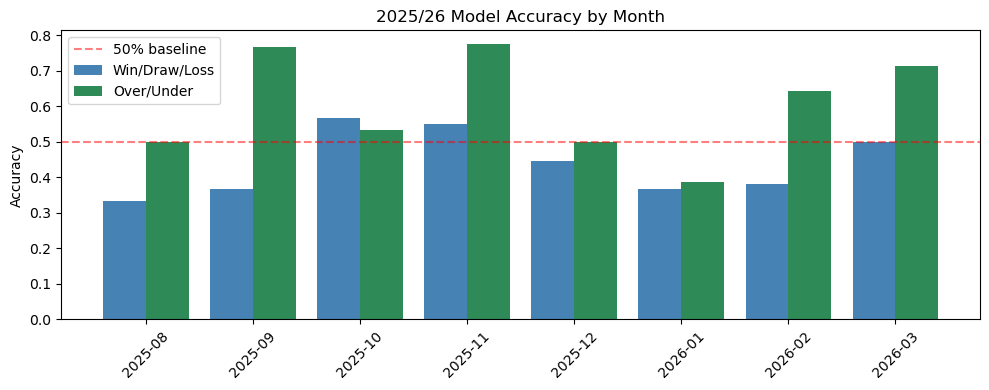

In [30]:
# 5c. Accuracy by Month
played['month'] = played['Date'].dt.to_period('M').astype(str)

monthly = played.groupby('month').agg(
    matches       = ('result_correct', 'count'),
    result_acc    = ('result_correct', 'mean'),
    ou_acc        = ('ou_correct', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(monthly))
ax.bar([i - 0.2 for i in x], monthly['result_acc'], width=0.4,
       label='Win/Draw/Loss', color='steelblue')
ax.bar([i + 0.2 for i in x], monthly['ou_acc'], width=0.4,
       label='Over/Under', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(monthly['month'], rotation=45)
ax.set_ylabel('Accuracy')
ax.set_title('2025/26 Model Accuracy by Month')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# 5d. Arsenal Results vs Predictions
arsenal = played[
    (played['HomeTeam'] == 'Arsenal') | (played['AwayTeam'] == 'Arsenal')
].copy()

arsenal['arsenal_home'] = (arsenal['HomeTeam'] == 'Arsenal')
arsenal['opponent'] = arsenal.apply(
    lambda r: r['AwayTeam'] if r['arsenal_home'] else r['HomeTeam'], axis=1
)
arsenal['arsenal_actual'] = arsenal.apply(
    lambda r: r['FTR'] if r['arsenal_home'] else ('H' if r['FTR'] == 'A' else ('A' if r['FTR'] == 'H' else 'D')), axis=1
)
arsenal['arsenal_pred'] = arsenal.apply(
    lambda r: r['pred_result'] if r['arsenal_home'] else ('H' if r['pred_result'] == 'A' else ('A' if r['pred_result'] == 'H' else 'D')), axis=1
)
arsenal['correct'] = (arsenal['arsenal_actual'] == arsenal['arsenal_pred']).astype(int)

print(f"Arsenal matches predicted : {len(arsenal)}")
print(f"Arsenal prediction accuracy : {arsenal['correct'].mean():.1%}")
print()
print(arsenal[['Date', 'opponent', 'arsenal_actual', 'arsenal_pred', 'correct']].to_string(index=False))

Arsenal matches predicted : 30
Arsenal prediction accuracy : 63.3%

      Date       opponent arsenal_actual arsenal_pred  correct
2025-08-17     Man United              H            A        0
2025-08-23          Leeds              H            H        1
2025-08-31      Liverpool              A            H        0
2025-09-13  Nott'm Forest              H            H        1
2025-09-21       Man City              D            H        0
2025-09-28      Newcastle              H            A        0
2025-10-04       West Ham              H            H        1
2025-10-18         Fulham              H            H        1
2025-10-26 Crystal Palace              H            H        1
2025-11-01        Burnley              H            H        1
2025-11-08     Sunderland              D            H        0
2025-11-23      Tottenham              H            H        1
2025-11-30        Chelsea              D            D        1
2025-12-03      Brentford              H          

## 6. Title Race Simulation
Monte Carlo simulation of the remaining fixtures — what are Arsenal's chances of winning the league?

In [32]:
# 6a. Get Remaining 2025/26 Fixtures
# We need fixtures not yet played — football-data only has played matches
# so we build the remaining fixtures manually from the full schedule

all_2526 = features[features['season'] == '2025-26'].copy()

# get all teams
teams = sorted(pd.concat([all_2526['HomeTeam'], all_2526['AwayTeam']]).unique())
print(f"Teams in 2025/26: {len(teams)}")
print(teams)

Teams in 2025/26: 20
['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Burnley', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Man City', 'Man United', 'Newcastle', "Nott'm Forest", 'Sunderland', 'Tottenham', 'West Ham', 'Wolves']


In [33]:
# 6b. Current Standings (from played matches)
def get_standings(df):
    rows = []
    for team in teams:
        home_games = df[df['HomeTeam'] == team]
        away_games = df[df['AwayTeam'] == team]

        pts  = (home_games['FTR'] == 'H').sum() * 3 + (home_games['FTR'] == 'D').sum()
        pts += (away_games['FTR'] == 'A').sum() * 3 + (away_games['FTR'] == 'D').sum()

        gf   = home_games['FTHG'].sum() + away_games['FTAG'].sum()
        ga   = home_games['FTAG'].sum() + away_games['FTHG'].sum()
        played = len(home_games) + len(away_games)

        rows.append({'team': team, 'played': played, 'pts': pts,
                     'gf': gf, 'ga': ga, 'gd': gf - ga})

    standings = pd.DataFrame(rows).sort_values(
        ['pts', 'gd', 'gf'], ascending=False
    ).reset_index(drop=True)
    standings.index += 1
    return standings

current_standings = get_standings(all_2526)
print("\n── Current 2025/26 Standings ──")
print(current_standings.to_string())


── Current 2025/26 Standings ──
              team  played  pts    gf    ga     gd
1          Arsenal      30   67 59.00 22.00  37.00
2         Man City      29   60 59.00 27.00  32.00
3       Man United      29   51 51.00 40.00  11.00
4      Aston Villa      29   51 39.00 34.00   5.00
5          Chelsea      29   48 53.00 34.00  19.00
6        Liverpool      29   48 48.00 39.00   9.00
7        Brentford      29   44 44.00 40.00   4.00
8          Everton      29   43 34.00 33.00   1.00
9      Bournemouth      29   40 44.00 46.00  -2.00
10          Fulham      29   40 40.00 43.00  -3.00
11      Sunderland      29   40 30.00 34.00  -4.00
12       Newcastle      29   39 42.00 43.00  -1.00
13  Crystal Palace      29   38 33.00 35.00  -2.00
14        Brighton      29   37 38.00 36.00   2.00
15           Leeds      29   31 37.00 48.00 -11.00
16       Tottenham      29   29 39.00 46.00  -7.00
17   Nott'm Forest      29   28 28.00 43.00 -15.00
18        West Ham      29   28 35.00 54.00 -19.0

In [34]:
# 6c. Build Remaining Fixtures
from itertools import permutations

# Full season = each pair plays home and away
all_fixtures = pd.DataFrame(
    [(h, a) for h, a in permutations(teams, 2)],
    columns=['HomeTeam', 'AwayTeam']
)

# Already played
played_pairs = all_2526[['HomeTeam', 'AwayTeam']].apply(tuple, axis=1).tolist()

# Remaining = all fixtures minus played
remaining = all_fixtures[
    ~all_fixtures.apply(tuple, axis=1).isin(played_pairs)
].reset_index(drop=True)

print(f"Total fixtures in a season : {len(all_fixtures)}")
print(f"Already played             : {len(played_pairs)}")
print(f"Remaining                  : {len(remaining)}")

Total fixtures in a season : 380
Already played             : 291
Remaining                  : 89


In [35]:
# 6d. Get Form for Each Remaining Fixture

remaining_rows = []
for _, match in remaining.iterrows():
    home, away = match['HomeTeam'], match['AwayTeam']

    home_form = compute_form(get_team_form(features, home, pd.Timestamp.today()), home)
    away_form = compute_form(get_team_form(features, away, pd.Timestamp.today()), away)

    remaining_rows.append({
        'HomeTeam':     home,
        'AwayTeam':     away,
        'h_form_pts':   home_form['form_pts'],
        'h_form_gf':    home_form['form_gf'],
        'h_form_ga':    home_form['form_ga'],
        'h_form_sot_f': home_form['form_sot_f'],
        'h_form_sot_a': home_form['form_sot_a'],
        'a_form_pts':   away_form['form_pts'],
        'a_form_gf':    away_form['form_gf'],
        'a_form_ga':    away_form['form_ga'],
        'a_form_sot_f': away_form['form_sot_f'],
        'a_form_sot_a': away_form['form_sot_a'],
        'pts_diff':     home_form['form_pts']   - away_form['form_pts'],
        'gf_diff':      home_form['form_gf']    - away_form['form_gf'],
        'ga_diff':      home_form['form_ga']    - away_form['form_ga'],
        'sot_diff':     (home_form['form_sot_f'] or 0) - (away_form['form_sot_f'] or 0),
    })

remaining_features = pd.DataFrame(remaining_rows).fillna(0)

# ← swapped to Logistic Regression
remaining_probs = lr_outcome.predict_proba(remaining_features[FEATURE_COLS])

In [36]:
# 6e. Monte Carlo Simulation (10,000 runs)
import random

N_SIMS = 10_000

# Starting points from current standings
base_pts = current_standings.set_index('team')['pts'].to_dict()
base_gd  = current_standings.set_index('team')['gd'].to_dict()

title_count    = {team: 0 for team in teams}
top4_count     = {team: 0 for team in teams}
relegated_count = {team: 0 for team in teams}

for sim in range(N_SIMS):
    sim_pts = base_pts.copy()
    sim_gd  = base_gd.copy()

    for i, match in remaining.iterrows():
        home, away = match['HomeTeam'], match['AwayTeam']
        p_h, p_d, p_a = remaining_probs[i]

        outcome = random.choices(['H', 'D', 'A'], weights=[p_h, p_d, p_a])[0]

        if outcome == 'H':
            sim_pts[home] += 3
            sim_gd[home]  += 1
            sim_gd[away]  -= 1
        elif outcome == 'D':
            sim_pts[home] += 1
            sim_pts[away] += 1
        else:
            sim_pts[away] += 3
            sim_gd[away]  += 1
            sim_gd[home]  -= 1

    # Final table for this simulation
    final = sorted(teams, key=lambda t: (sim_pts[t], sim_gd[t]), reverse=True)

    title_count[final[0]]     += 1
    for t in final[:4]:
        top4_count[t]          += 1
    for t in final[-3:]:
        relegated_count[t]     += 1

In [37]:
# 6f. Results
sim_results = pd.DataFrame({
    'team':        teams,
    'title_%':     [title_count[t]     / N_SIMS * 100 for t in teams],
    'top4_%':      [top4_count[t]      / N_SIMS * 100 for t in teams],
    'relegated_%': [relegated_count[t] / N_SIMS * 100 for t in teams],
}).sort_values('title_%', ascending=False).reset_index(drop=True)

sim_results.index += 1
print(sim_results.to_string())

              team  title_%  top4_%  relegated_%
1          Arsenal    88.62  100.00         0.00
2         Man City    11.26   99.68         0.00
3       Man United     0.08   66.46         0.00
4      Aston Villa     0.04   45.81         0.00
5         West Ham     0.00    0.00        32.28
6        Tottenham     0.00    0.00        30.56
7       Sunderland     0.00    0.19         0.01
8    Nott'm Forest     0.00    0.00        30.91
9        Newcastle     0.00    0.10         0.03
10       Liverpool     0.00   36.93         0.00
11           Leeds     0.00    0.00         8.61
12          Fulham     0.00    0.35         0.00
13         Everton     0.00    2.91         0.00
14  Crystal Palace     0.00    0.14         0.05
15         Chelsea     0.00   41.96         0.00
16         Burnley     0.00    0.00        97.57
17        Brighton     0.00    0.08         0.15
18       Brentford     0.00    5.15         0.00
19     Bournemouth     0.00    0.24         0.03
20          Wolves  

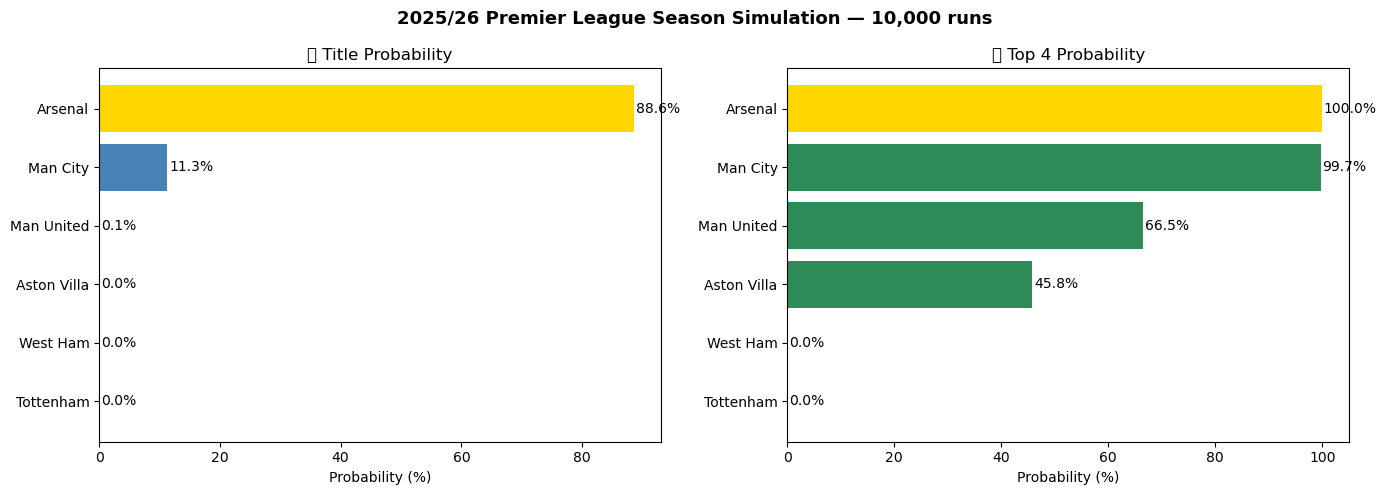

In [38]:
# 6g. Title Race Chart
top6 = sim_results.head(6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Title probability
colors = ['gold' if t == 'Arsenal' else 'steelblue' for t in top6['team']]
axes[0].barh(top6['team'][::-1], top6['title_%'][::-1], color=colors[::-1])
axes[0].set_xlabel('Probability (%)')
axes[0].set_title('🏆 Title Probability')
for i, (v, t) in enumerate(zip(top6['title_%'][::-1], top6['team'][::-1])):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center')

# Top 4 probability
colors2 = ['gold' if t == 'Arsenal' else 'seagreen' for t in top6['team']]
axes[1].barh(top6['team'][::-1], top6['top4_%'][::-1], color=colors2[::-1])
axes[1].set_xlabel('Probability (%)')
axes[1].set_title('🎯 Top 4 Probability')
for i, (v, t) in enumerate(zip(top6['top4_%'][::-1], top6['team'][::-1])):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.suptitle('2025/26 Premier League Season Simulation — 10,000 runs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Visualizations

Seven-Chart Summary

In [39]:
# 7a. Imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

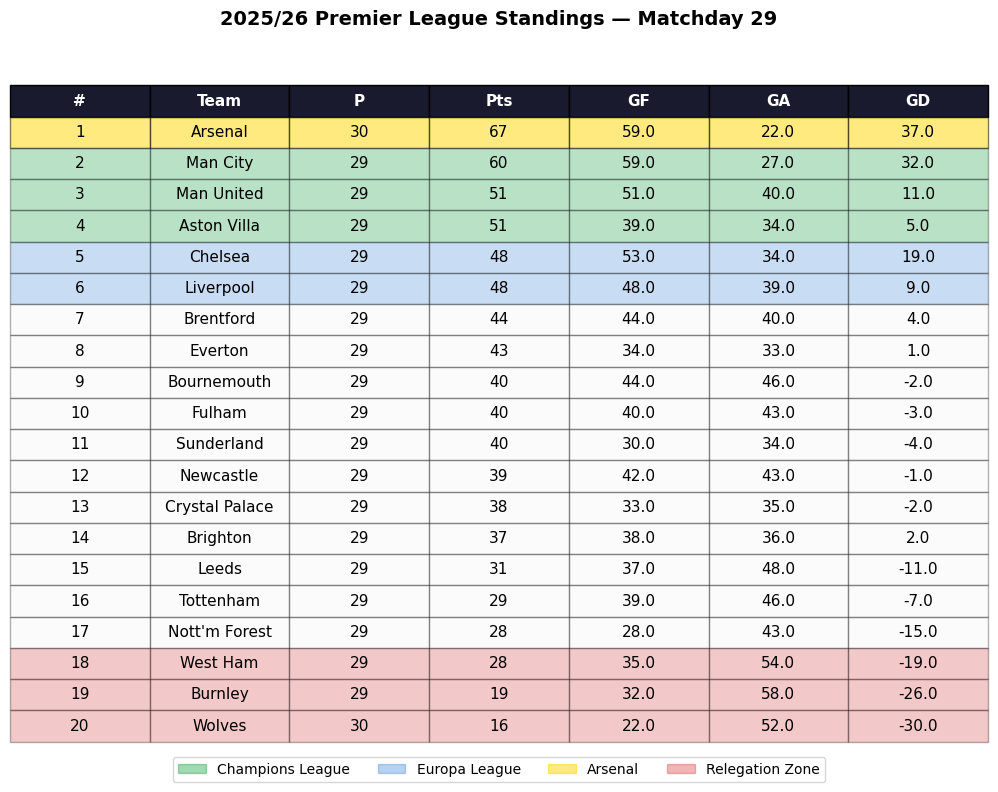

In [40]:
# 7b. Current Standings Table Visual
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')

colors = []
for i, row in current_standings.iterrows():
    if i <= 4:
        colors.append('#1a9e3f')      # Champions League — green
    elif i <= 6:
        colors.append('#4a90d9')      # Europa — blue
    elif i >= 18:
        colors.append('#d94a4a')      # Relegation — red
    else:
        colors.append('#f5f5f5')      # Mid table — light

table_data = current_standings[['team','played','pts','gf','ga','gd']].values.tolist()
table_data = [[i+1] + row for i, row in enumerate(table_data)]

col_labels = ['#', 'Team', 'P', 'Pts', 'GF', 'GA', 'GD']
t = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1.2, 1.6)

for j in range(len(col_labels)):
    t[0, j].set_facecolor('#1a1a2e')
    t[0, j].set_text_props(color='white', fontweight='bold')

for i, color in enumerate(colors):
    for j in range(len(col_labels)):
        t[i+1, j].set_facecolor(color)
        t[i+1, j].set_alpha(0.3)
        if current_standings.iloc[i]['team'] == 'Arsenal':
            t[i+1, j].set_facecolor('gold')
            t[i+1, j].set_alpha(0.5)

legend_elements = [
    mpatches.Patch(color='#1a9e3f', alpha=0.4, label='Champions League'),
    mpatches.Patch(color='#4a90d9', alpha=0.4, label='Europa League'),
    mpatches.Patch(color='gold',    alpha=0.5, label='Arsenal'),
    mpatches.Patch(color='#d94a4a', alpha=0.4, label='Relegation Zone'),
]
ax.legend(handles=legend_elements, loc='lower center',
          bbox_to_anchor=(0.5, -0.02), ncol=4)

ax.set_title('2025/26 Premier League Standings — Matchday 29',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

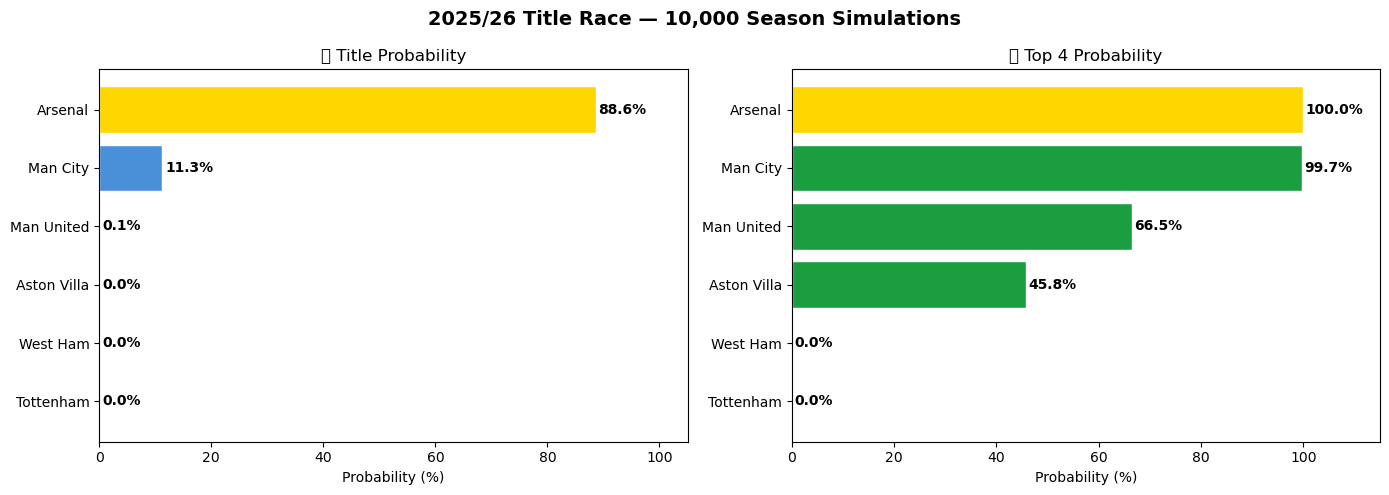

In [41]:
# 7c. Title Race Simulation Chart
top6 = sim_results.head(6)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('2025/26 Title Race — 10,000 Season Simulations',
             fontsize=14, fontweight='bold')

# Title probability
title_colors = ['gold' if t == 'Arsenal' else '#4a90d9' for t in top6['team']]
bars = axes[0].barh(top6['team'][::-1], top6['title_%'][::-1],
                    color=title_colors[::-1], edgecolor='white')
axes[0].set_xlabel('Probability (%)')
axes[0].set_title('🏆 Title Probability')
axes[0].set_xlim(0, 105)
for i, v in enumerate(top6['title_%'][::-1]):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

# Top 4 probability
top4_colors = ['gold' if t == 'Arsenal' else '#1a9e3f' for t in top6['team']]
axes[1].barh(top6['team'][::-1], top6['top4_%'][::-1],
             color=top4_colors[::-1], edgecolor='white')
axes[1].set_xlabel('Probability (%)')
axes[1].set_title('🎯 Top 4 Probability')
axes[1].set_xlim(0, 115)
for i, v in enumerate(top6['top4_%'][::-1]):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

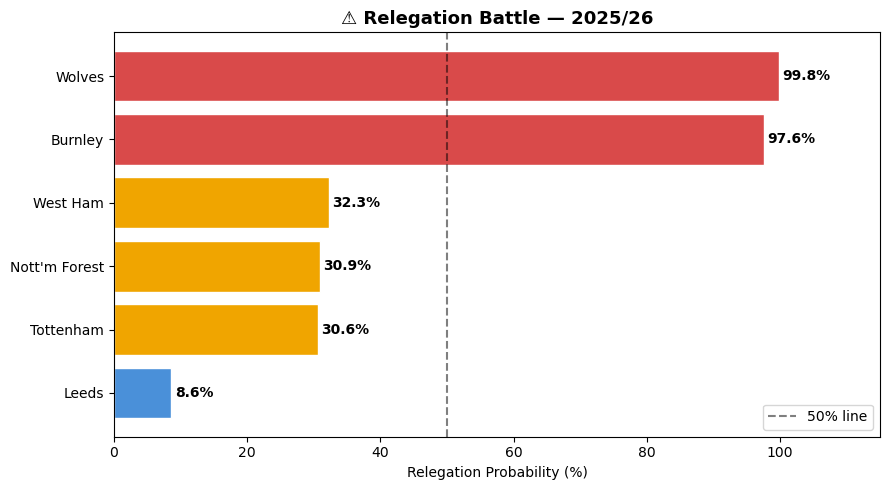

In [42]:
# 7d. Relegation Battle Chart
bottom6 = sim_results.sort_values('relegated_%', ascending=False).head(6)

fig, ax = plt.subplots(figsize=(9, 5))

rel_colors = ['#d94a4a' if v > 50 else '#f0a500' if v > 15 else '#4a90d9'
              for v in bottom6['relegated_%']]

ax.barh(bottom6['team'][::-1], bottom6['relegated_%'][::-1],
        color=rel_colors[::-1], edgecolor='white')
ax.axvline(50, color='black', linestyle='--', alpha=0.5, label='50% line')
ax.set_xlabel('Relegation Probability (%)')
ax.set_title('⚠️ Relegation Battle — 2025/26', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
for i, v in enumerate(bottom6['relegated_%'][::-1]):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

ax.legend()
plt.tight_layout()
plt.show()

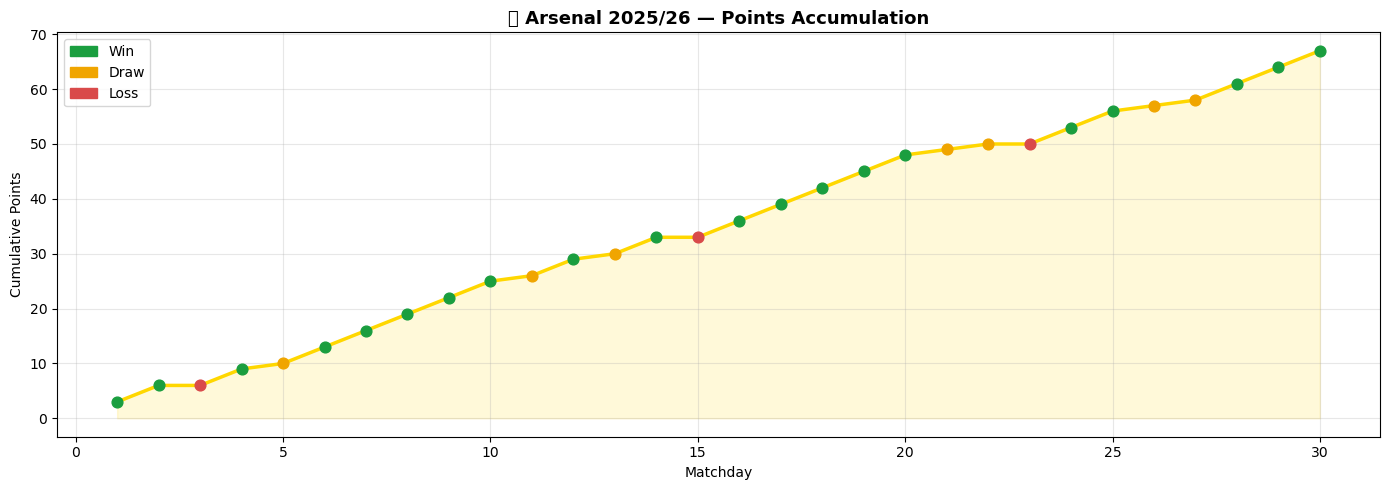

In [43]:
# 7e. Arsenal Season Journey — Points Accumulation
arsenal_played = all_2526[
    (all_2526['HomeTeam'] == 'Arsenal') |
    (all_2526['AwayTeam'] == 'Arsenal')
].copy().sort_values('Date').reset_index(drop=True)

arsenal_played['arsenal_home'] = arsenal_played['HomeTeam'] == 'Arsenal'
arsenal_played['pts_gained'] = arsenal_played.apply(
    lambda r: 3 if (r['arsenal_home'] and r['FTR'] == 'H') or
                   (not r['arsenal_home'] and r['FTR'] == 'A')
              else 1 if r['FTR'] == 'D' else 0, axis=1
)
arsenal_played['cumulative_pts'] = arsenal_played['pts_gained'].cumsum()
arsenal_played['matchday'] = range(1, len(arsenal_played) + 1)
arsenal_played['opponent'] = arsenal_played.apply(
    lambda r: r['AwayTeam'] if r['arsenal_home'] else r['HomeTeam'], axis=1
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(arsenal_played['matchday'],
                arsenal_played['cumulative_pts'],
                alpha=0.15, color='gold')
ax.plot(arsenal_played['matchday'],
        arsenal_played['cumulative_pts'],
        color='gold', linewidth=2.5, marker='o', markersize=5)

# Colour each point by result
for _, row in arsenal_played.iterrows():
    color = '#1a9e3f' if row['pts_gained'] == 3 else \
            '#f0a500' if row['pts_gained'] == 1 else '#d94a4a'
    ax.scatter(row['matchday'], row['cumulative_pts'], color=color, s=60, zorder=5)

legend_elements = [
    mpatches.Patch(color='#1a9e3f', label='Win'),
    mpatches.Patch(color='#f0a500', label='Draw'),
    mpatches.Patch(color='#d94a4a', label='Loss'),
]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_xlabel('Matchday')
ax.set_ylabel('Cumulative Points')
ax.set_title('⚽ Arsenal 2025/26 — Points Accumulation',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

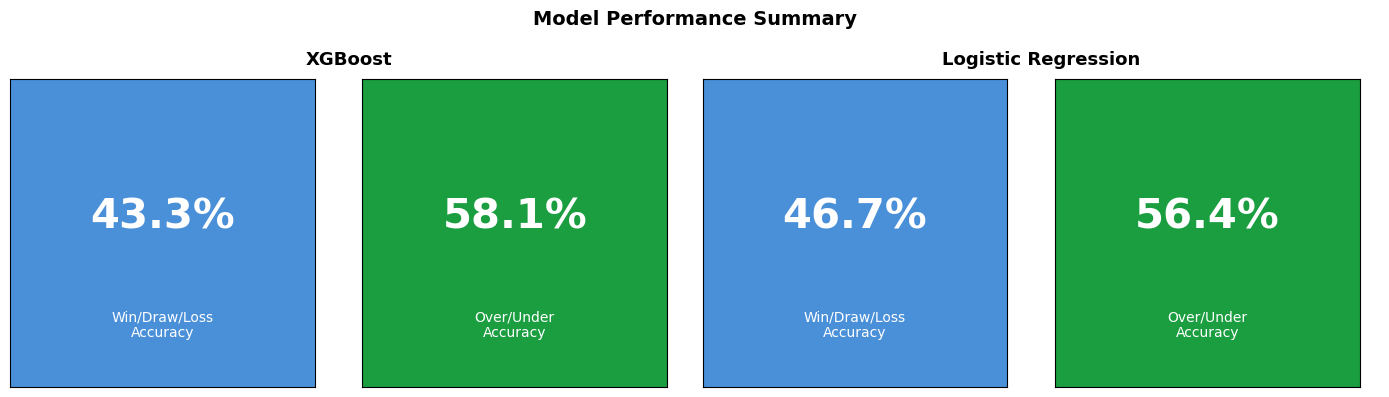

In [44]:
# 7f. Model Accuracy Summary Card
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')

# XGBoost
xgb_metrics = [
    ('Win/Draw/Loss\nAccuracy', f"{acc:.1%}",    '#4a90d9'),
    ('Over/Under\nAccuracy',    f"{acc_ou:.1%}", '#1a9e3f'),
]

# Logistic Regression
lr_metrics = [
    ('Win/Draw/Loss\nAccuracy', f"{lr_acc:.1%}",    '#4a90d9'),
    ('Over/Under\nAccuracy',    f"{lr_acc_ou:.1%}", '#1a9e3f'),
]

for ax_idx, (title, metrics) in enumerate(
    [('XGBoost', xgb_metrics), ('Logistic Regression', lr_metrics)]
):
    ax_group = axes[ax_idx]
    ax_group.axis('off')
    ax_group.set_title(title, fontsize=13, fontweight='bold', pad=10)

    for i, (label, value, color) in enumerate(metrics):
        inset = ax_group.inset_axes([i * 0.52, 0, 0.45, 1])
        inset.set_facecolor(color)
        inset.text(0.5, 0.55, value, ha='center', va='center',
                   fontsize=30, fontweight='bold',
                   transform=inset.transAxes, color='white')
        inset.text(0.5, 0.2, label, ha='center', va='center',
                   fontsize=10, transform=inset.transAxes, color='white')
        inset.set_xticks([])
        inset.set_yticks([])

plt.tight_layout()
plt.show()